In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/julia/ViscousStreaming.jl`


In [2]:
using Revise
using ViscousStreaming

[ Info: Precompiling ViscousStreaming [47fb7046-13b0-40db-b6a6-74fa44cf0959] (cache misses: include_dependency fsize change (2))


In [3]:
using Plots

In [4]:
# markdown display disable
import Markdown
Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [5]:
DDF_TYPE = CartesianGrids.Yang3

CartesianGrids.Yang3

In [6]:
Re = 40

40

In [39]:
spacing = 1.4 
Δx = 0.02
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx;nthreads_max=4)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)
# body = Square(1.0, Δs)
cache = SurfaceVectorCache(body, g)

Surface cache with scaling of type GridScaling
  224 point data of type VectorData{224, Float64, Vector{Float64}}
  Grid data of type Edges{Primal, 600, 600, Float64, Vector{Float64}}


In [40]:
my_params = Dict()
my_params["Re"] = Re;

In [41]:
function get_vsplus1(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    vsplus.u .= 1
    return vsplus
end
function get_vsminus1(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    vsminus.u .= 1
    return vsminus
end

bcdict1 = Dict("exterior"=>get_vsplus1,"interior"=>get_vsminus1);

In [42]:
function get_vsplus2(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    return vsplus
end
function get_vsminus2(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    return vsminus
end

bcdict2 = Dict("exterior"=>get_vsplus2,"interior"=>get_vsminus2);

In [43]:
prob_iner = ViscousStreaming.ViscousStreamingInertialProblem(g,body,scaling=GridScaling,bc=bcdict1, dtype=ComplexF64, phys_params = my_params, ddftype=DDF_TYPE)
@time sys_iner = construct_system(prob_iner);

 53.249763 seconds (8.87 M allocations: 23.616 GiB, 2.31% gc time, 4.35% compilation time)


In [44]:
prob_noniner = ViscousStreaming.ViscousStreamingNonInertialProblem(g,body,scaling=GridScaling,bc=bcdict2,dtype=ComplexF64, phys_params = my_params, ddftype=DDF_TYPE)
@time sys_noniner = construct_system(prob_noniner);

 50.218481 seconds (687.52 k allocations: 23.205 GiB, 1.60% gc time, 0.09% compilation time)


In [45]:
@time v1_iner, s1_iner, σ1_iner, v2_iner, s2_iner, σ2_iner = ImmersedLayers.solve(prob_iner,sys_iner)
nothing

  4.192201 seconds (21.89 M allocations: 1.538 GiB, 2.36% gc time, 90.47% compilation time)


In [46]:
@time v1_noniner, s1_noniner, σ1_noniner, v2_noniner, s2_noniner, σ2_noniner = ImmersedLayers.solve(prob_noniner,sys_noniner)
nothing

  1.006301 seconds (788.88 k allocations: 459.026 MiB, 7.23% gc time, 56.55% compilation time)


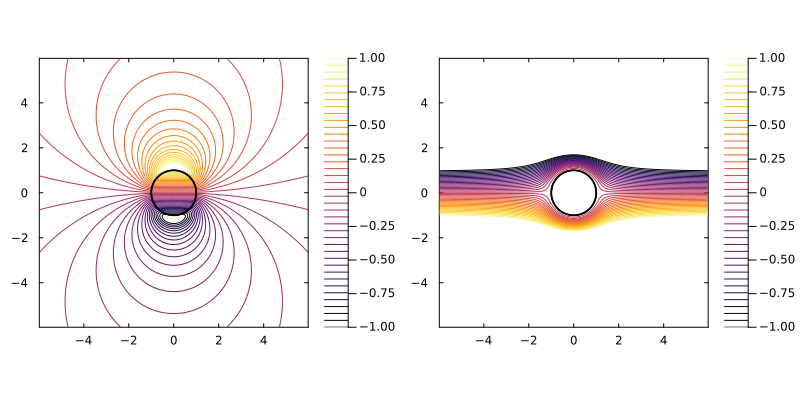

In [47]:
p1 = plot(real(s1_iner),sys_iner, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)
p2 = plot(real(s1_noniner),sys_noniner, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)
plot(p1,p2,layout=(1,2), size=(800,400))

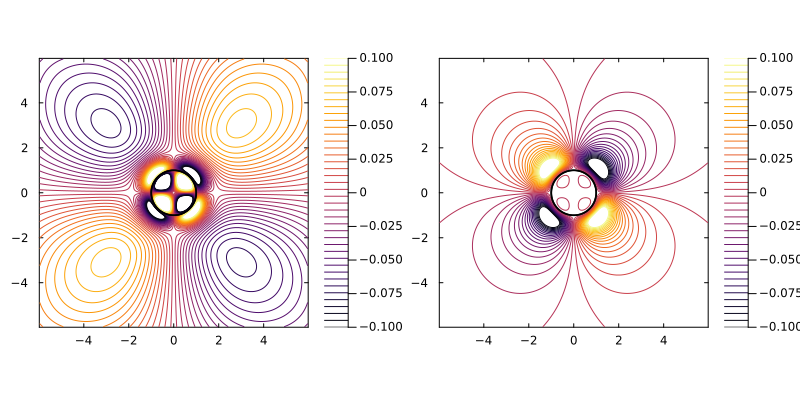

In [48]:
p1 = plot(real(s2_iner),sys_iner, levels=range(-0.1,0.1,length=40),clim=(-0.1,0.1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)
p2 = plot(real(s2_noniner),sys_noniner, levels=range(-0.1,0.1,length=40),clim=(-0.1,0.1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)
plot(p1,p2,layout=(1,2), size=(800,400))

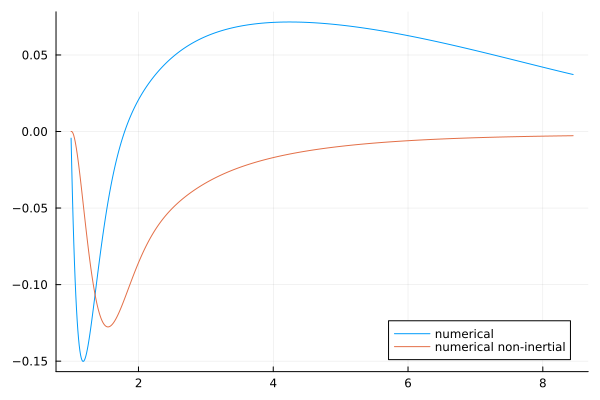

In [49]:
s2_iner_itp = interpolatable_field(real(s2_iner), sys_iner);
s2_noniner_itp = interpolatable_field(real(s2_noniner), sys_noniner);
r = 1:0.01:Lx/sqrt(2)
plot(r, s2_iner_itp.(r/sqrt(2), r/sqrt(2)), label="numerical")
plot!(r, s2_noniner_itp.(r/sqrt(2), r/sqrt(2)), label="numerical non-inertial")